# Convex Hull & Ordering Analysis

Clean analysis notebook for comparing FP vs DFT on:
- **Convex hull** (tie-line formation energies, agreement metrics)
- **Ordering** (top-k recall, Spearman correlation)

Right after Section 0's imports, **"Using FPBench with another dataset"** is a
standalone public-interface guide: how to run this benchmark's own metrics on
your own data. It is not part of the manuscript reproduction and is not
numbered. Sections 1-6 below it reproduce the manuscript's own PCM
(phase-change-material) analyses from the two standardized files this
benchmark ships.

**Sections**
| # | Title |
|---|-------|
| 0 | Imports & setup |
| — | *Using FPBench with another dataset (public interface guide)* |
| 1 | Load and validate standardized benchmark data |
| 2 | Data-structure demonstration |
| 3 | Configuration |
| 4 | Convex hull and relative phase stability |
| 5 | Energy rankings of elemental orderings |
| 6 | Structural relaxation effects (RMSD) |

---
**Note on DFT energies.** All DFT energies used throughout this benchmark (binary tie-line endpoints and interior tie-line compositions) are raw, uncorrected VASP-PBE energies — no Materials Project MP2020 compatibility correction is applied anywhere. Verified against the Materials Project API for the binary endpoint entries (stored energies match `uncorrected_energy`, not the corrected `energy` field); the interior tie-line structures are this project's own DFT-PBE relaxations and were never MP-corrected either. This will be documented properly in the GitHub README / leaderboard write-up.

---
## Section 0 — Imports & setup

In [1]:
import json
import sys
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, "../scripts")

from convexhull_analysis_utils import (
    # T — canonical standardized-file loaders + FP display constants
    load_standardized_reference, load_standardized_results,
    PHASE_STABILITY_ORDERING_MODEL_ORDER, PHASE_STABILITY_ORDERING_MODEL_NAMES,
    # J/K/L — metrics (used by the table builders below, also available for direct use)
    ground_state_agreement_pooled, within_phase_hull_min_agreement, global_hull_min_agreement,
    is_misranked_pair, _test_is_misranked_pair,
    # N — FPBench data validation summary
    validate_phase_stability_ordering_results,
    # P — modularized demonstration plot
    plot_hull_pair_demo,
    # R — one-call results-table builders
    build_combined_hull_table, build_combined_ordering_table, build_rmsd_table,
    # S — public builder for datasets beyond this project's own standardized files
    build_phase_stability_ordering_results,
)

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120

_ok, _results = _test_is_misranked_pair()
assert _ok, f"ranking-error unit tests failed: {_results}"
print("Imports OK. Ranking-error unit tests (correct/reversed/DFT-tie/FP-tie/both-tied): PASS")

Imports OK. Ranking-error unit tests (correct/reversed/DFT-tie/FP-tie/both-tied): PASS


---
## Using FPBench with another dataset

FPBench's phase-stability and ordering analysis separates three steps:

1. **Preparing standardized DFT reference data and FP results** -- your own
   tie-line systems, candidates, phases, compositions, and ordering groups,
   with the energies and structures the metrics below need.
2. **Validating those data** -- identifiers line up, required fields are
   present, ordering groups are complete, and every FP/protocol's results
   are accounted for, including what is missing.
3. **Calculating the convex-hull, ordering, and RMSD metrics** -- the same
   functions Sections 1-6 use to reproduce the manuscript's own PCM
   (phase-change-material) dataset.

You provide your DFT reference data and your FP calculation results. You do
not need to provide your calculator code, and you do not need to reproduce
FPBench's own historical file organization -- Sections 1-6 below load two
standardized files, themselves produced once, offline, from this project's
own historical raw data files; that raw file layout is not part of the
public interface and this notebook's normal path never touches it.

**Two protocols, evaluated separately:**

- **Full FP relaxation**: the FP relaxes each structure itself, starting
  from `initial_structure`. Atomic positions are relaxed; cell shape and
  volume are held fixed throughout (a fixed-cell relaxation). Requires the
  FP's own energy *and* its own relaxed structure for every candidate --
  needed for the RMSD comparison (Section 6) and for the within-phase /
  global hull-minimum metrics, which recompute each candidate's tie-line
  fraction from that structure.
- **Static FP evaluation on DFT-relaxed structures**: the FP evaluates the
  energy of the DFT-relaxed structure (`relaxed_structure`) without relaxing
  it. Requires only the FP's energy for that structure; no separate FP
  structure is needed or used.

For both protocols, a candidate you have a result for is recorded with
`status: "success"` and its `energy_total`; a candidate you don't have a
result for is `status: "missing"`, `"failed"`, or `"non_converged"` (or
simply omitted, which is treated the same as `"missing"`) -- only
`status: "success"` records are ever scored, but the distinct label is
preserved and reported separately by the validator. A missing FP-relaxed
structure is never replaced by the DFT structure.

```text
Paper reproduction:

provided standardized PCM reference data + FP results
                         |
              standardized FPBench data structures
                         |
          hull, ordering, and RMSD analyses


Using FPBench on another dataset:

DFT reference data + FP results
for full relaxation and static evaluation
                         |
build_phase_stability_ordering_results(...)
                         |
        same standardized FPBench data structures
                         |
          same FPBench analysis functions
```

### The public function workflow

```python
from convexhull_analysis_utils import (
    build_phase_stability_ordering_results,
    validate_phase_stability_ordering_results,
    build_combined_hull_table,
    build_combined_ordering_table,
    build_rmsd_table,
)
```

`build_phase_stability_ordering_results(...)` constructs the standardized
FPBench data structures from your `reference_data` and `fp_results`:

```python
benchmark_results = build_phase_stability_ordering_results(
    reference_data=reference_data,
    fp_results=fp_results,
)

dft_hull = benchmark_results["dft_hull"]
fp_hull = benchmark_results["fp_hull"]
dft_ordering = benchmark_results["dft_ordering"]
fp_ordering = benchmark_results["fp_ordering"]

fp_names = list(fp_results)
```

`validate_phase_stability_ordering_results(...)` checks identifiers, required
fields, group completeness, protocol completeness, and missing/failed/
non-converged results, and prints a summary report:

```python
validation_report = validate_phase_stability_ordering_results(
    dft_hull=dft_hull,
    fp_hull_by_fp=fp_hull,
    dft_ordering=dft_ordering,
    fp_ordering_by_fp=fp_ordering,
    fps=fp_names,
)
```

Then the three analysis calls -- the same ones Sections 4-6 use below:

```python
hull_table, hull_details = build_combined_hull_table(
    dft_hull, fp_hull, fp_names, model_names
)

ordering_table, ordering_details = build_combined_ordering_table(
    dft_ordering, fp_ordering, fp_names, model_names
)

rmsd_table, rmsd_records, rmsd_details = build_rmsd_table(
    dft_hull, fp_hull, fp_names, model_names
)
```

- `build_combined_hull_table(...)` calculates the phase-stability and
  convex-hull metrics (average energy error, ground-state agreement,
  within-phase and global hull-minimum agreement).
- `build_combined_ordering_table(...)` calculates the elemental-ordering
  metrics (average energy error, top-1 accuracy, recall@k, Spearman ρ, rate
  of ranking errors, ΔE_DFT of misranked pairs).
- `build_rmsd_table(...)` calculates mapping success and structural-
  relaxation RMSD metrics.

These five functions are the whole public workflow. They call lower-level
metric functions internally (`ground_state_agreement_pooled`,
`within_phase_hull_min_agreement`, `global_hull_min_agreement`,
`compute_structure_rmsd`, `compute_ordering_group_metrics`, and others) --
you do not need to call or understand those directly to reproduce or extend
any table in this notebook.

### The input contract

This is `build_phase_stability_ordering_results`'s actual accepted schema
(see its full docstring in `convexhull_analysis_utils.py`, Section S, for
every field):

```python
reference_data = {
    "hull": {                                    # optional -- omit if no hull benchmark
        tie_line_system: {
            candidate_id: {
                "role": "interior" | "endpoint",       # required
                "phase_id": phase_identifier,           # required
                "composition": composition_identifier,  # required, free-form label
                "energy_total": dft_total_energy_eV,    # required
                "relaxed_structure": pymatgen_structure_dict,   # required
                "initial_structure": pymatgen_structure_dict,   # optional
                "n_atoms": int,                          # optional; derived from relaxed_structure
                "x": tie_line_fraction,                  # optional, provenance only (see below)
                "endpoint_side": "left" | "right",       # required iff role == "endpoint"
            },
        },
    },
    "ordering": {                                 # optional -- omit if no ordering benchmark
        ordering_group_id: {
            "system": tie_line_system,                  # optional, provenance only
            "phase_id": phase_identifier,                # required
            "composition": composition_identifier,       # required
            "orderings": {                                # exactly 20 entries required
                ordering_candidate_id: {
                    "energy_total": dft_total_energy_eV,       # required
                    "n_atoms": int,                             # optional; derived from relaxed_structure
                    "relaxed_structure": pymatgen_structure_dict,  # optional, provenance only
                    "initial_structure": pymatgen_structure_dict,  # optional
                },
            },
        },
    },
}

fp_results = {
    fp_name: {
        "hull": {
            "relax": {                                    # full FP relaxation
                tie_line_system: {
                    candidate_id: {
                        "status": "success"|"missing"|"failed"|"non_converged",
                        "energy_total": fp_total_energy_eV,
                        "relaxed_structure": pymatgen_structure_dict,
                    },
                },
            },
            "static": {                                   # static FP evaluation on the DFT-relaxed structure
                tie_line_system: {
                    candidate_id: {
                        "status": "success"|"missing"|"failed"|"non_converged",
                        "energy_total": fp_total_energy_eV,
                    },
                },
            },
        },
        "ordering": {
            "relax":  {ordering_group_id: {ordering_candidate_id: {"status": ..., "energy_total": ...}}},
            "static": {ordering_group_id: {ordering_candidate_id: {"status": ..., "energy_total": ...}}},
        },
    },
}
```

**Required natural identifiers**: tie-line system (`tie_line_system`),
candidate identifier (`candidate_id`), phase identifier (`phase_id`),
composition identifier (`composition`), endpoint role and side
(`role`/`endpoint_side`, for endpoint candidates only), ordering-group
identifier (`ordering_group_id`, the `reference_data["ordering"]` /
`fp_results[fp]["ordering"][mode]` key), ordering-candidate identifier
(`ordering_candidate_id`, an entry in `"orderings"`), and calculation
protocol (`"relax"` or `"static"`).

`candidate_id` and `ordering_group_id`/`ordering_candidate_id` only need to
be stable and unique within their own documented scope (a candidate_id
unique among its own system's candidates, or among all endpoints; an
ordering_candidate_id unique within its own group) -- they do not need to
encode `phase_id` or any other identifier.

**Energies**: `energy_total` (DFT and FP alike) is always a total energy, in
eV, for the whole structure. `build_phase_stability_ordering_results`
computes every per-atom energy itself, from `energy_total` and the atom
count (`n_atoms` if given, else the atom count of `relaxed_structure`) -- it
is never taken as a caller-supplied field, so DFT and every FP end up
normalized the same way by construction.

The `x` field on a hull candidate (its position along the tie-line) is
stored for reference only. `within_phase_hull_min_agreement` and
`global_hull_min_agreement` recompute it geometrically from the candidate's
own relaxed structure and the two endmember formulas parsed out of
`tie_line_system`, so `tie_line_system` should be `"{formula_A}_{formula_B}"`
(two pymatgen-parsable chemical formulas) for those two metrics to be
meaningful; average energy error and ground-state agreement do not depend on
that convention.

### Reproducing FPBench from the standardized files

The public analysis contract is always the Python `reference_data` and
`fp_results` structures above -- you are never required to serialize your
data as JSON or `.json.gz`. This project's own manuscript reproduction
happens to keep its `reference_data`/`fp_results` on disk as two
standardized files, purely as this project's own convenient, versionable,
checksummed storage format for its own large dataset:

```text
Provided FPBench reproduction:

standardized DFT reference
        +
standardized merged all-model FP results
        |
build_phase_stability_ordering_results(...)
        |
validation
        |
hull, ordering and RMSD analyses
```

```python
reference_payload = load_standardized_reference("data/phase_stability_ordering_reference.json.gz")
results_payload   = load_standardized_results("data/phase_stability_ordering_results_standardized.json.gz")

reference_data = reference_payload["reference_data"]
fp_results     = results_payload["models"]           # {"mace": {...}, "chgnet": {...}, ...}
```

From here it is the identical `build_phase_stability_ordering_results` ->
`validate_phase_stability_ordering_results` -> table-builder workflow
described above -- Section 1 below does exactly this.

**Adding another FP later** (the workflow `generation/convexhull_ordering_run_generator.ipynb` uses):
each FP's own run produces one standardized single-model fragment, which
`merge_phase_stability_ordering_fp_results(...)` adds into the common
all-model results file -- it validates the fragment's schema/dataset/
reference-checksum against the existing file and every candidate/ordering
identifier it references against the shared reference, and never silently
overwrites an already-present model:

```text
Adding another FP later:

standardized single-FP result fragment
        |
merge_phase_stability_ordering_fp_results(...)
        |
updated standardized all-model FP results
        |
same analysis workflow
```

```python
updated_results = merge_phase_stability_ordering_fp_results(
    fragments={"new_fp_key": new_fp_fragment},   # or a path to a fragment .json/.json.gz
    reference_data=reference_data,
    reference_sha256=results_payload["reference"]["sha256"],
    existing_models=results_payload,
    out_path="data/phase_stability_ordering_results_standardized.json.gz",  # optional
)
fp_results = updated_results["models"]
```

### Demonstration

In [2]:
with open("../examples/phase_stability_ordering_demo_data.json") as f:
    demo_input = json.load(f)

# demo_benchmark_results is deliberately separate from dft_hull/fp_hull/
# dft_ordering/fp_ordering built in Section 1 below -- it covers one system +
# one ordering group for one FP, not the manuscript benchmark, and is not
# referenced by any results cell in Sections 4-6.
demo_benchmark_results = build_phase_stability_ordering_results(
    reference_data=demo_input["reference_data"], fp_results=demo_input["fp_results"],
)
print("build_phase_stability_ordering_results returned:", list(demo_benchmark_results.keys()))

DEMO_MODEL_NAMES = {"mace": "MACE"}
DEMO_FPS = list(demo_input["fp_results"])

demo_validation_report = validate_phase_stability_ordering_results(
    dft_hull=demo_benchmark_results["dft_hull"],
    fp_hull_by_fp=demo_benchmark_results["fp_hull"],
    dft_ordering=demo_benchmark_results["dft_ordering"],
    fp_ordering_by_fp=demo_benchmark_results["fp_ordering"],
    fps=DEMO_FPS,
)

print("\nSame build_combined_hull_table(...) call as Section 4, run on the one-system demo data above\n"
      "(illustrative only -- not a manuscript result):")
demo_hull_table, demo_hull_details = build_combined_hull_table(
    demo_benchmark_results["dft_hull"], demo_benchmark_results["fp_hull"], DEMO_FPS, DEMO_MODEL_NAMES,
)
display(demo_hull_table)

print("\nSame build_combined_ordering_table(...) call as Section 5, run on the one-group demo data above\n"
      "(illustrative only -- not a manuscript result):")
demo_ordering_table, demo_ordering_details = build_combined_ordering_table(
    demo_benchmark_results["dft_ordering"], demo_benchmark_results["fp_ordering"], DEMO_FPS, DEMO_MODEL_NAMES,
)
display(demo_ordering_table)

print("\nSame build_rmsd_table(...) call as Section 6, run on the one-system demo data above\n"
      "(illustrative only -- not a manuscript result):")
demo_rmsd_table, demo_rmsd_records, demo_rmsd_details = build_rmsd_table(
    demo_benchmark_results["dft_hull"], demo_benchmark_results["fp_hull"], DEMO_FPS, DEMO_MODEL_NAMES,
)
display(demo_rmsd_table)

build_phase_stability_ordering_results returned: ['dft_hull', 'fp_hull', 'dft_ordering', 'fp_ordering']
══════════════════════════════════════════════════════════════════════════════
FPBENCH DATA VALIDATION SUMMARY
══════════════════════════════════════════════════════════════════════════════

Hull:
  n_systems: 1
  n_unique_interior_candidates: 8
  n_interior_appearances: 8
  n_unique_endpoints: 2
  n_total_unique_candidates: 10

Ordering:
  n_groups: 1
  orderings_per_group: 20 (all groups, enforced)
  n_records: 20

Common hull candidates across all 1 FPs (both protocols must have status=success):
  relax: 10 / 10
  static: 10 / 10

Common COMPLETE ordering groups across all 1 FPs:
  relax: 1 / 1
  static: 1 / 1

Missing hull records by FP/protocol:
  mace                  relax=   0  static=   0

Missing ordering records by FP/protocol:
  mace                  relax=   0  static=   0

Non-success status breakdown by FP/protocol (hull):

Non-success status breakdown by FP/protocol (

Full FP relaxation                              \
     Average energy error (meV/atom) Ground- state agreement (%)   
FP                                                                 
MACE                              69                      100.00   

                                                                         \
     Within-phase hull-minimum agreement (%) Hull-minimum agreement (%)   
FP                                                                        
MACE                                    0.00                       0.00   

     Static FP evaluations on the DFT-relaxed structures  \
                         Average energy error (meV/atom)   
FP                                                         
MACE                                                 22    

                                                                          \
     Ground- state agreement (%) Within-phase hull-minimum agreement (%)   
FP                                                                         
MACE                      100.00                                    0.00   

                                 
     Hull-minimum agreement (%)  
FP                               
MACE                       0.00


Same build_combined_ordering_table(...) call as Section 5, run on the one-group demo data above
(illustrative only -- not a manuscript result):


,,Average energy error (meV/atom) ↓,Top-1 accuracy (%) ↑,Recall@3 (%) ↑,Recall@10 (%) ↑,Spearman ρ ↑,Rate of ranking errors (%) ↓,Mean/max ΔE_DFT (meV/atom) ↓
,FP,,,,,,,
Full FP relaxation,MACE,23,0.0000,100.0000,50.0000,0.5600,28.9000,4 / 10
Static FP evaluations on the DFT-relaxed structures,MACE,5,100.0000,100.0000,50.0000,0.6800,20.5000,3 / 10



Same build_rmsd_table(...) call as Section 6, run on the one-system demo data above
(illustrative only -- not a manuscript result):


,Map success (%),Mean/max RMSD (Å),RMSD < 0.05 Å (%),RMSD < 0.10 Å (%),RMSD < 0.20 Å (%)
FP,,,,,
MACE,100.00,0.56 / 1.00,20.00,20.00,20.00


---
## Section 1 — Load and validate standardized benchmark data

Loads the two canonical standardized files this benchmark ships --
`data/phase_stability_ordering_reference.json.gz` (the shared DFT reference)
and `data/phase_stability_ordering_results_standardized.json.gz` (all seven
FPs' results, under one `"models"` mapping) -- and builds `dft_hull` /
`fp_hull` / `dft_ordering` / `fp_ordering` via the same public
`build_phase_stability_ordering_results(...)` documented above, then
immediately validates them with `validate_phase_stability_ordering_results(...)`.
This is exactly the "Provided FPBench reproduction" workflow from that
section -- manuscript reproduction and "using FPBench with another dataset"
now share the same code path, differing only in where `reference_data` /
`fp_results` come from. See Section 2 for what the resulting data actually
looks like.

The two standardized files are themselves produced once, offline, by
`scripts/convert_legacy_phase_stability_ordering_data.py` from this
project's historical raw data files -- that conversion script (and the raw
files it reads) is not part of the normal analysis path and is not run from
this notebook.

In [3]:
# ── The two canonical standardized files (repository-relative paths) ───────
DATA_DIR = Path("../data")
REFERENCE_PATH = DATA_DIR / "phase_stability_ordering_reference.json.gz"
RESULTS_PATH   = DATA_DIR / "phase_stability_ordering_results_standardized.json.gz"

reference_payload = load_standardized_reference(REFERENCE_PATH)
results_payload   = load_standardized_results(RESULTS_PATH)

# The results file records the sha256 of the reference file it was merged
# against; verify this notebook's reference file is genuinely that one,
# rather than trusting the two filenames to agree by convention alone.
_actual_reference_sha256 = hashlib.sha256(REFERENCE_PATH.read_bytes()).hexdigest()
assert _actual_reference_sha256 == results_payload["reference"]["sha256"], (
    f"{REFERENCE_PATH} does not match the reference "
    f"{RESULTS_PATH} was standardized against (sha256 mismatch)."
)

reference_data = reference_payload["reference_data"]
fp_results     = results_payload["models"]

benchmark_results = build_phase_stability_ordering_results(
    reference_data=reference_data,
    fp_results=fp_results,
)

dft_hull     = benchmark_results["dft_hull"]
fp_hull      = benchmark_results["fp_hull"]
dft_ordering = benchmark_results["dft_ordering"]
fp_ordering  = benchmark_results["fp_ordering"]

BENCHMARK_FPS = list(fp_results)
print(f"Loaded {REFERENCE_PATH.name} (sha256={_actual_reference_sha256[:12]}...) "
      f"and {RESULTS_PATH.name} for {len(BENCHMARK_FPS)} FPs: {BENCHMARK_FPS}")
print(f"dft_hull: {len(dft_hull)} systems  |  dft_ordering: {len(dft_ordering)} groups")

Loaded phase_stability_ordering_reference.json.gz (sha256=1b6addae634f...) and phase_stability_ordering_results_standardized.json.gz for 7 FPs: ['chgnet', 'm3gnet_matpes_pbe', 'm3gnet_mp', 'mace', 'mace_matpes_pbe', 'tensornet_pbe', 'uma']
dft_hull: 22 systems  |  dft_ordering: 305 groups


In [4]:
validation_report = validate_phase_stability_ordering_results(
    dft_hull=dft_hull,
    fp_hull_by_fp=fp_hull,
    dft_ordering=dft_ordering,
    fp_ordering_by_fp=fp_ordering,
    fps=BENCHMARK_FPS,
)

══════════════════════════════════════════════════════════════════════════════
FPBENCH DATA VALIDATION SUMMARY
══════════════════════════════════════════════════════════════════════════════

Hull:
  n_systems: 22
  n_unique_interior_candidates: 561
  n_interior_appearances: 561
  n_unique_endpoints: 36
  n_total_unique_candidates: 597

Ordering:
  n_groups: 305
  orderings_per_group: 20 (all groups, enforced)
  n_records: 6100

Common hull candidates across all 7 FPs (both protocols must have status=success):
  relax: 597 / 597
  static: 597 / 597

Common COMPLETE ordering groups across all 7 FPs:
  relax: 305 / 305
  static: 305 / 305

Missing hull records by FP/protocol:
  chgnet                relax=   0  static=   0
  m3gnet_matpes_pbe     relax=   0  static=   0
  m3gnet_mp             relax=   0  static=   0
  mace                  relax=   0  static=   0
  mace_matpes_pbe       relax=   0  static=   0
  tensornet_pbe         relax=   0  static=   0
  uma                   relax=

---
## Section 2 — Data-structure demonstration

The standardized data model this notebook is built on. `dft_hull`/`fp_hull` cover the convex-hull benchmark; `dft_ordering`/`fp_ordering` cover the ordering benchmark. Both come from the same public builder, whether the source is this project's own standardized files or another dataset entirely:

```python
benchmark_results = build_phase_stability_ordering_results(
    reference_data=reference_data,   # shared DFT reference: hull + ordering
    fp_results=fp_results,           # one entry per FP: hull + ordering, relax + static
)
dft_hull, fp_hull = benchmark_results["dft_hull"], benchmark_results["fp_hull"]
dft_ordering, fp_ordering = benchmark_results["dft_ordering"], benchmark_results["fp_ordering"]
```

In this notebook, Section 1 loads `reference_data` from `data/phase_stability_ordering_reference.json.gz` and `fp_results` from `data/phase_stability_ordering_results_standardized.json.gz` and passes them straight into that one call. What the result actually looks like, for one real candidate of each kind:

In [5]:
_demo_fp = "mace"  # any FP key from BENCHMARK_FPS -- mace is just this demonstration's chosen FP; the DFT reference itself is model-independent
_sys = next(iter(dft_hull))
_interior_id = next(cid for cid, e in dft_hull[_sys].items() if e["role"] == "interior")
_endpoint_id = next(cid for cid, e in dft_hull[_sys].items() if e["role"] == "endpoint")

def _no_structs(d):
    return {k: v for k, v in d.items() if "structure" not in k}

print(f"dft_hull[{_sys!r}][{_interior_id!r}] =\n  {_no_structs(dft_hull[_sys][_interior_id])}\n")
print(f"fp_hull['{_demo_fp}']['relax'][{_sys!r}][{_interior_id!r}] =\n"
      f"  {_no_structs(fp_hull[_demo_fp]['relax'][_sys][_interior_id])}\n")
print(f"dft_hull[{_sys!r}][{_endpoint_id!r}] (endpoint) =\n  {_no_structs(dft_hull[_sys][_endpoint_id])}\n")

_group = next(iter(dft_ordering))
_name = next(iter(dft_ordering[_group]["orderings"]))
print(f"dft_ordering[{_group!r}]['orderings'][{_name!r}] =\n"
      f"  {_no_structs(dft_ordering[_group]['orderings'][_name])}\n")
print(f"fp_ordering['{_demo_fp}']['relax'][{_group!r}][{_name!r}] =\n"
      f"  {fp_ordering[_demo_fp]['relax'][_group][_name]}")

dft_hull['Bi2Se3_Sb2Se3']['mp-1198150_Bi3+12_Sb3+4_Se2-24'] =
  {'candidate_id': 'mp-1198150_Bi3+12_Sb3+4_Se2-24', 'source_keys': {'origin': 'user_provided'}, 'role': 'interior', 'phase_id': 'mp-1198150', 'composition': 'mp-1198150_Bi3+12_Sb3+4_Se2-24', 'x': 0.25, 'n_atoms': 40, 'energy_total': -155.23130697, 'energy_per_atom': -3.88078267425}

fp_hull['mace']['relax']['Bi2Se3_Sb2Se3']['mp-1198150_Bi3+12_Sb3+4_Se2-24'] =
  {'status': 'success', 'energy_total': -156.01982362278085, 'energy_per_atom': -3.900495590569521}

dft_hull['Bi2Se3_Sb2Se3']['mp-1198150'] (endpoint) =
  {'candidate_id': 'mp-1198150', 'source_keys': {'origin': 'user_provided'}, 'role': 'endpoint', 'phase_id': 'mp-1198150', 'composition': 'Bi16 Se24', 'x': 0.0, 'n_atoms': 40, 'energy_total': -155.66707401, 'energy_per_atom': -3.8916768502499997, 'endpoint_side': 'left'}

dft_ordering['mp-10074_Ge4+1_Sn2+3_Se2-5']['orderings']['ordered_0'] =
  {'n_atoms': 9, 'energy_total': -36.04175429, 'energy_per_atom': -4.00463936

---
## Section 3 — Configuration

In [6]:
# ── FP display order (used for every table/figure in this notebook) ────────
PAPER_ORDER = [fp for fp in PHASE_STABILITY_ORDERING_MODEL_ORDER if fp in BENCHMARK_FPS]
print("FPs to analyse:", PAPER_ORDER)

ALL_SYSTEMS = sorted(dft_hull)
print(f"Systems: {ALL_SYSTEMS[:5]} … ({len(ALL_SYSTEMS)} total)")

MODEL_NAMES    = PHASE_STABILITY_ORDERING_MODEL_NAMES
PAPER_NAME_MAP = MODEL_NAMES

FPs to analyse: ['mace', 'chgnet', 'm3gnet_mp', 'uma', 'm3gnet_matpes_pbe', 'tensornet_pbe', 'mace_matpes_pbe']
Systems: ['Bi2Se3_Sb2Se3', 'Bi2Se3_SiSe2', 'Bi2Te3_SiTe2', 'GeSe2_Bi2Se3', 'GeSe2_SiSe2'] … (22 total)


In [7]:
# ── Dataset population (already finalized by the standardized reference) ───
# The standardized reference file only ever contains the 22 systems that
# have both tie-line endpoints -- there is nothing left to detect or filter
# here; this just states the resulting counts directly from dft_hull.
n_interior  = sum(1 for s in dft_hull for cid, e in dft_hull[s].items() if e["role"] == "interior")
n_endpoints = len({cid for s in dft_hull for cid, e in dft_hull[s].items() if e["role"] == "endpoint"})
print(f"This dataset contains {len(ALL_SYSTEMS)} ternary tie-line systems "
      f"and {n_interior + n_endpoints} DFT-relaxed structures "
      f"({n_interior} interior + {n_endpoints} unique binary endpoints).")

This dataset contains 22 ternary tie-line systems and 597 DFT-relaxed structures (561 interior + 36 unique binary endpoints).


---
## Section 4 — Convex hull and relative phase stability

Ground-state agreement, within-phase hull-minimum agreement, and hull-minimum agreement, evaluated for Full FP relaxation and Static FP evaluations on DFT-relaxed structures (Table 3/4 in the manuscript).

| Metric | Description |
|--------|-------------|
| Average energy error | Energy error relative to DFT, reported as MAE over all structures in the dataset (includes defected/substituted structures with different orderings), in meV/atom. |
| Ground- state agreement | For each composition, the FP-predicted lowest-energy phase is compared with DFT. Reported as the fraction of compositions, across all tie-line systems, for which the two agree. **Pooled** across all systems directly (not macro-averaged per system), and **single-phase compositions are excluded** from both the numerator and denominator -- a composition with only one candidate phase provides no real choice for the FP to get right or wrong. |
| Within-phase hull-minimum agreement | For each phase, the FP-predicted minimum-energy composition is compared with DFT (tie-line-normalized energies). Reported as the fraction of phases, across all tie-line systems, for which the two agree; single-composition phases are excluded. |
| Hull-minimum agreement | For each tie-line system, the FP-predicted global convex-hull minimum is compared with DFT (tie-line-normalized energies). Reported as the fraction of systems for which the two agree. |

### Results

In [8]:
combined_hull_table, hull_rows_by_mode = build_combined_hull_table(dft_hull, fp_hull, PAPER_ORDER, PAPER_NAME_MAP)
combined_hull_table.index.name = "FP"
print("Aggregate summary — Full FP relaxation + Static FP evaluations on the DFT-relaxed structures")
display(combined_hull_table)

print("\nGround-state agreement — numerator/denominator (pooled, single-phase excluded), Full FP relaxation:")
for fp in PAPER_ORDER:
    gs = hull_rows_by_mode["relax"][fp]["_gs"]
    print(f"  {PAPER_NAME_MAP.get(fp,fp):20s}  {gs['numerator']:3d}/{gs['denominator']:3d}"
          f"  (excluded {gs['excluded_single_phase_instances']} single-phase compositions)")

print("\nHull-minimum agreement — numerator/denominator, Full FP relaxation:")
for fp in PAPER_ORDER:
    gh = hull_rows_by_mode["relax"][fp]["_gh"]
    print(f"  {PAPER_NAME_MAP.get(fp,fp):20s}  {gh['numerator']:2d}/{gh['denominator']:2d}")

Aggregate summary — Full FP relaxation + Static FP evaluations on the DFT-relaxed structures


Full FP relaxation                              \
                 Average energy error (meV/atom) Ground- state agreement (%)   
FP                                                                             
MACE                                          48                       69.09   
CHGNet                                       241                       57.58   
M3GNet                                        49                       60.00   
UMA                                           78                       69.09   
M3GNet-MatPES                                115                       48.48   
TensorNet-MatPES                              86                       59.39   
MACE-MatPES                                   86                       54.55   

                                                          \
                 Within-phase hull-minimum agreement (%)   
FP                                                         
MACE                                               61.98   
CHGNet                                             42.15   
M3GNet                                             47.93   
UMA                                                60.33   
M3GNet-MatPES                                      57.85   
TensorNet-MatPES                                   60.33   
MACE-MatPES                                        65.29   

                                             \
                 Hull-minimum agreement (%)   
FP                                            
MACE                                  40.91   
CHGNet                                18.18   
M3GNet                                18.18   
UMA                                   36.36   
M3GNet-MatPES                         22.73   
TensorNet-MatPES                      13.64   
MACE-MatPES                           18.18   

                 Static FP evaluations on the DFT-relaxed structures  \
                                     Average energy error (meV/atom)   
FP                                                                     
MACE                                                             14    
CHGNet                                                          244    
M3GNet                                                           34    
UMA                                                              43    
M3GNet-MatPES                                                   111    
TensorNet-MatPES                                                 66    
MACE-MatPES                                                      56    

                                              \
                 Ground- state agreement (%)   
FP                                             
MACE                                   69.09   
CHGNet                                 56.97   
M3GNet                                 58.18   
UMA                                    76.36   
M3GNet-MatPES                          47.88   
TensorNet-MatPES                       53.94   
MACE-MatPES                            54.55   

                                                          \
                 Within-phase hull-minimum agreement (%)   
FP                                                         
MACE                                               73.55   
CHGNet                                             45.45   
M3GNet                                             62.81   
UMA                                                78.51   
M3GNet-MatPES                                      57.85   
TensorNet-MatPES                                   66.94   
MACE-MatPES                                        75.21   

                                             
                 Hull-minimum agreement (%)  
FP                                           
MACE                                  40.91  
CHGNet                                22.73  
M3GNet                                22.73  
UMA                                   40.91  
M3GNet-MatPES                   


Ground-state agreement — numerator/denominator (pooled, single-phase excluded), Full FP relaxation:
  MACE                  114/165  (excluded 153 single-phase compositions)
  CHGNet                 95/165  (excluded 153 single-phase compositions)
  M3GNet                 99/165  (excluded 153 single-phase compositions)
  UMA                   114/165  (excluded 153 single-phase compositions)
  M3GNet-MatPES          80/165  (excluded 153 single-phase compositions)
  TensorNet-MatPES       98/165  (excluded 153 single-phase compositions)
  MACE-MatPES            90/165  (excluded 153 single-phase compositions)

Hull-minimum agreement — numerator/denominator, Full FP relaxation:
  MACE                   9/22
  CHGNet                 4/22
  M3GNet                 4/22
  UMA                    8/22
  M3GNet-MatPES          5/22
  TensorNet-MatPES       3/22
  MACE-MatPES            4/22


### Demonstration

One system, one FP: relax vs. static hull panels, coloured by phase, side by side.

In [9]:
DEMO_SYSTEM = "GeSe2_SiSe2"
DEMO_FP     = PAPER_ORDER[0]

print(f"Available systems ({len(ALL_SYSTEMS)}):", ALL_SYSTEMS)

Available systems (22): ['Bi2Se3_Sb2Se3', 'Bi2Se3_SiSe2', 'Bi2Te3_SiTe2', 'GeSe2_Bi2Se3', 'GeSe2_SiSe2', 'GeSe2_SnSe', 'GeSe_Sb2Se3', 'GeTe_Bi2Te3', 'GeTe_Ga2Te3', 'GeTe_GeSe', 'GeTe_SiTe2', 'GeTe_SnTe', 'GeTe_TiTe2', 'Sb2Te3_In2Te3', 'SnSe2_Bi2Se3', 'SnSe_Bi2Se3', 'SnSe_Sb2Se3', 'SnSe_SiSe2', 'SnTe_Bi2Te3', 'SnTe_Sb2Te3', 'SnTe_SnSe', 'TiTe2_Sb2Te3']


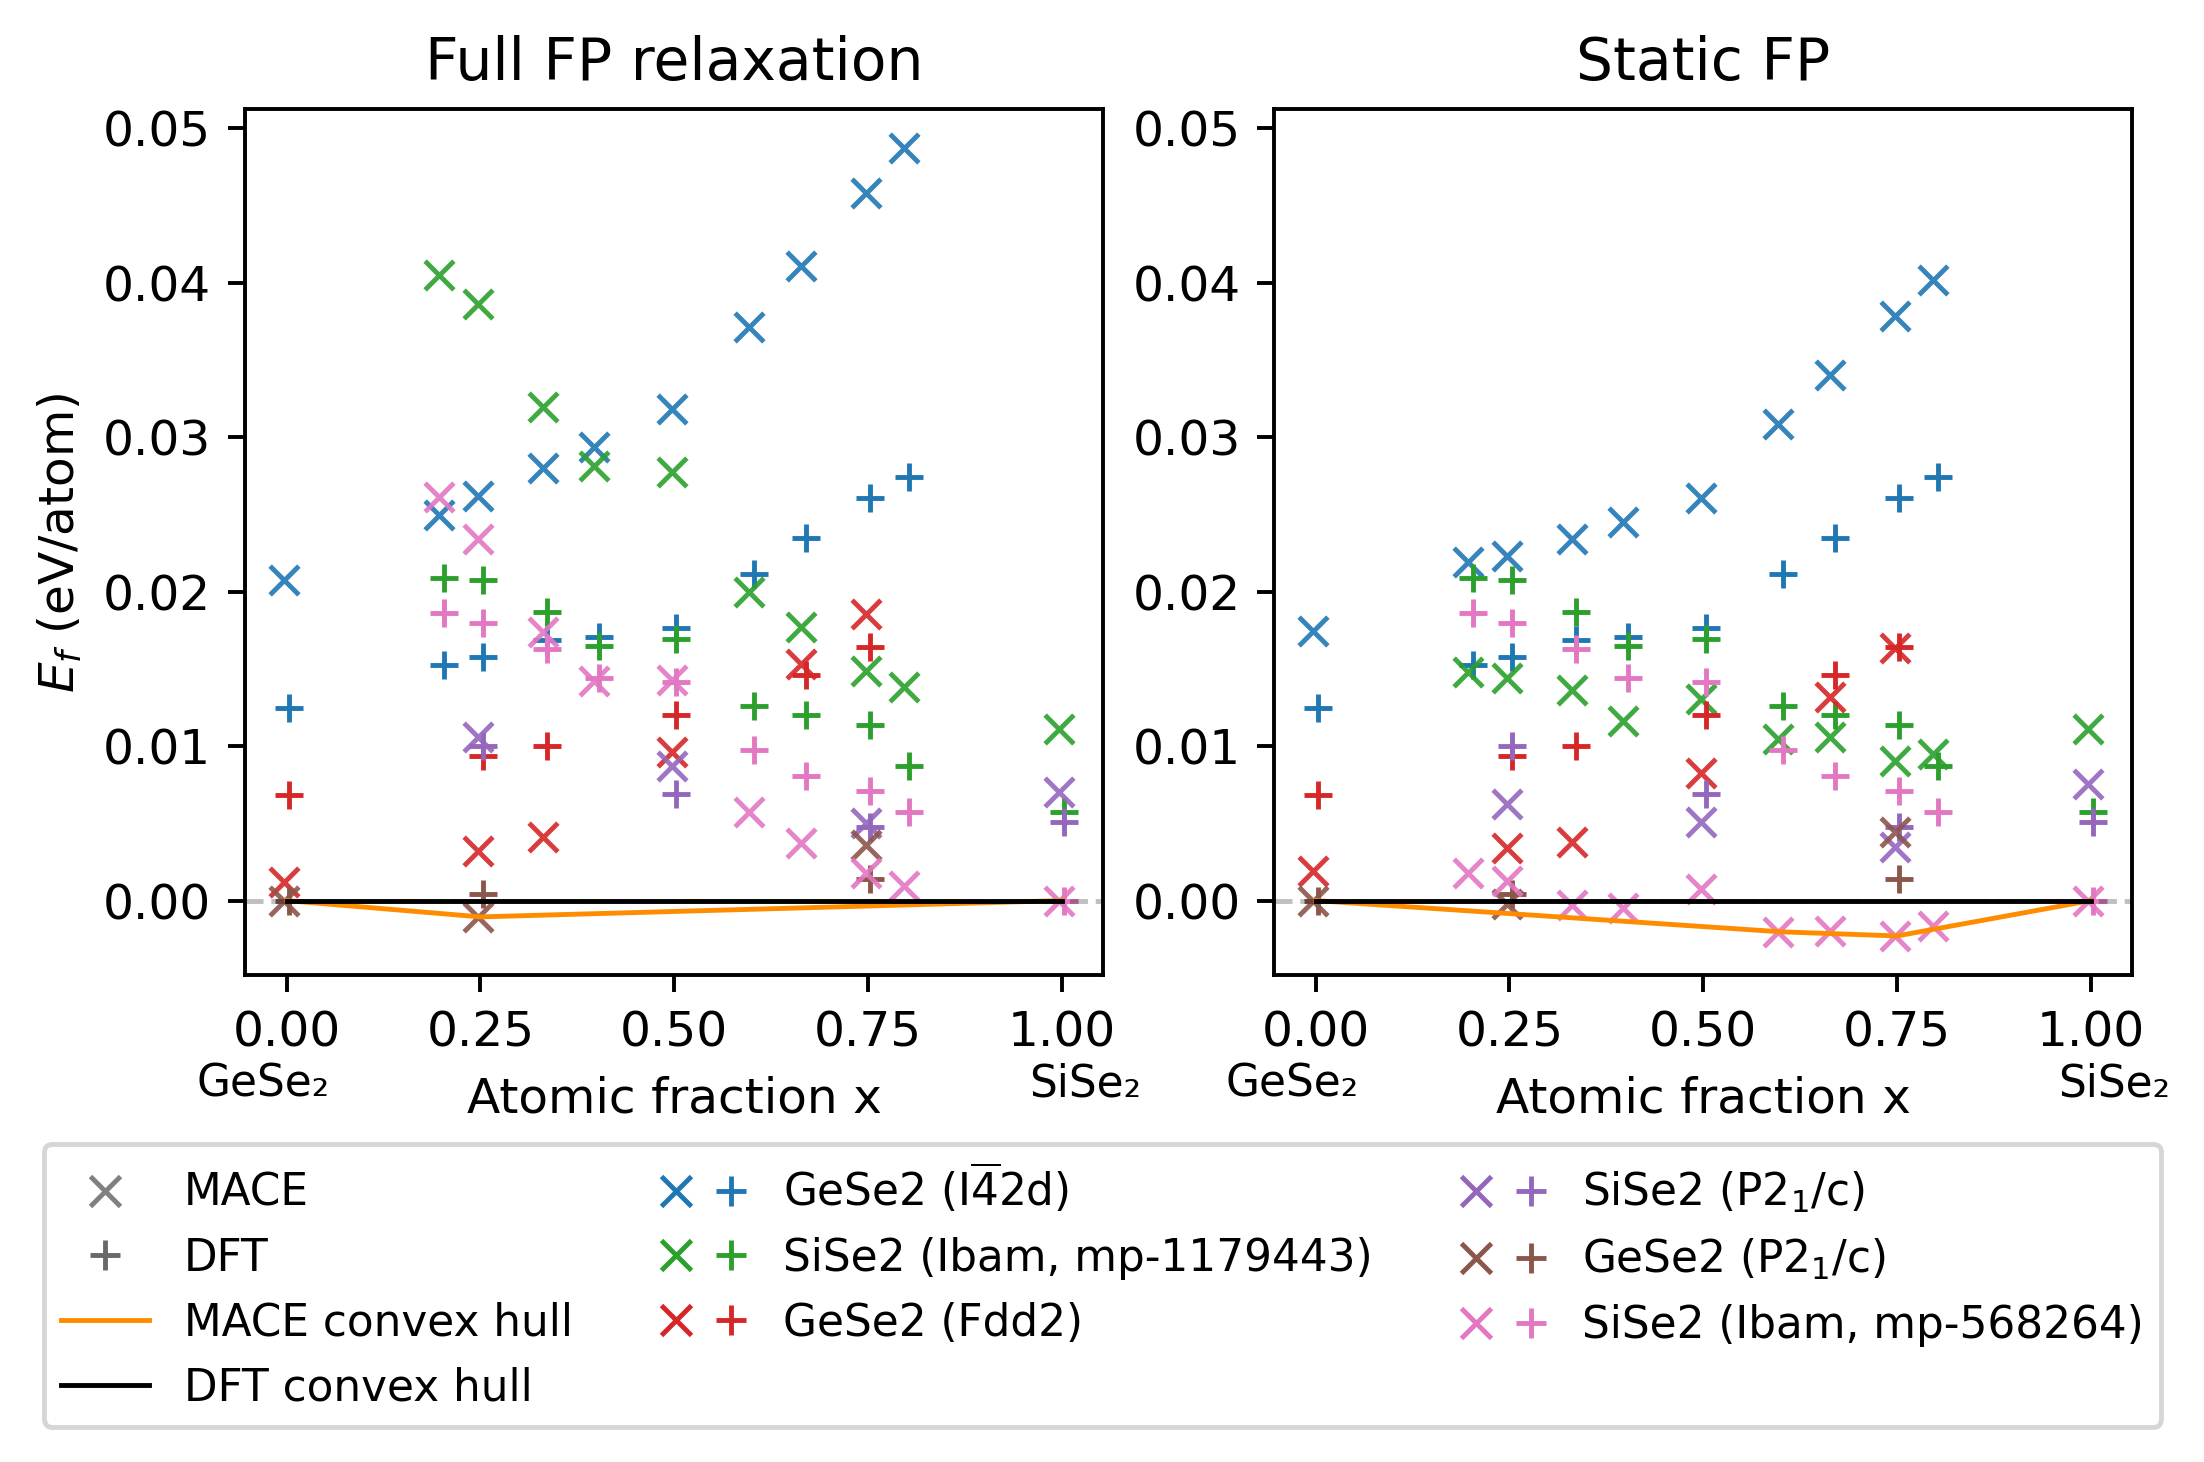

(<Figure size 2240x1155 with 2 Axes>,
 array([<Axes: title={'center': 'Full FP relaxation'}, xlabel='Atomic fraction x', ylabel='$E_f$ (eV/atom)'>,
        <Axes: title={'center': 'Static FP'}, xlabel='Atomic fraction x'>],
       dtype=object))

In [10]:
plot_hull_pair_demo(
    dft_hull, fp_hull,
    DEMO_FP, DEMO_SYSTEM, MODEL_NAMES,
)

---
## Section 5 — Energy rankings of elemental orderings

Uses `dft_ordering` / `fp_ordering` (Section 1). An ordering group is a 20-structure set of the lowest-DFT-energy elemental/vacancy orderings for a fixed phase and composition (Table 5 in the manuscript); 305 groups after deduplicating the 8 filesystem-casing-alias duplicates (Section 1).

| Metric | Description |
|--------|-------------|
| Average energy error | Energy error relative to DFT, reported as MAE over all structures in complete groups, in meV/atom. |
| Top-1 accuracy | Fraction of complete ordering groups for which the FP identifies the same lowest-energy configuration (LEC) as DFT. |
| Recall@3 / Recall@10 | Fraction of the k lowest-energy DFT orderings retained among the top-k FP-ranked orderings within each group, averaged over complete groups. |
| Spearman ρ | Rank correlation between FP and DFT orderings within each group, averaged over complete groups. |
| Rate of ranking errors | Fraction of configuration pairs whose FP and DFT rankings disagree, using the manuscript's exact condition `(E_dft_i - E_dft_j) * (E_fp_i - E_fp_j) <= 0` (a tie on either side counts as misranked — see the unit tests in Section 0), averaged over complete groups. |
| Mean/max ΔE_DFT | DFT energy difference between misranked configuration pairs; mean and maximum computed per group, then averaged across complete groups. |

A group is only scored for an FP/protocol if **all 20** of its DFT-selected `ordered_name`s have a successful FP result — an incomplete group is excluded, never scored as if it were complete.

### Results

In [11]:
combined_ordering_table, ordering_summaries = build_combined_ordering_table(
    dft_ordering, fp_ordering, PAPER_ORDER, PAPER_NAME_MAP,
)
print("Ordering metrics — Full FP relaxation + Static FP evaluations on the DFT-relaxed structures")
display(combined_ordering_table)

print("\nGroup completeness, Full FP relaxation:")
for fp in PAPER_ORDER:
    s = ordering_summaries[fp]["relax"]
    print(f"  {PAPER_NAME_MAP.get(fp,fp):20s}  complete={s['n_groups_complete']:3d}/{s['n_groups_total']:3d}"
          f"  incomplete={s['n_groups_incomplete']}")

Ordering metrics — Full FP relaxation + Static FP evaluations on the DFT-relaxed structures


Average energy error (meV/atom) ↓  \
                                                   FP                                                   
Full FP relaxation                                 MACE                                            43   
                                                   CHGNet                                         272   
                                                   M3GNet                                          56   
                                                   UMA                                             65   
                                                   M3GNet-MatPES                                   95   
                                                   TensorNet-MatPES                                69   
                                                   MACE-MatPES                                     69   
Static FP evaluations on the DFT-relaxed struct... MACE                                            14   
                                                   CHGNet                                         270   
                                                   M3GNet                                          41   
                                                   UMA                                             35   
                                                   M3GNet-MatPES                                   94   
                                                   TensorNet-MatPES                                52   
                                                   MACE-MatPES                                     43   

                                                                     Top-1 accuracy (%) ↑  \
                                                   FP                                       
Full FP relaxation                                 MACE                           23.6000   
                                                   CHGNet                          8.2000   
                                                   M3GNet                          7.2000   
                                                   UMA                            24.3000   
                                                   M3GNet-MatPES                  10.2000   
                                                   TensorNet-MatPES               12.8000   
                                                   MACE-MatPES                    21.3000   
Static FP evaluations on the DFT-relaxed struct... MACE                           46.6000   
                                                   CHGNet                         20.3000   
                                                   M3GNet                         22.3000   
                                                   UMA                            55.7000   
                                                   M3GNet-MatPES                  19.7000   
                                                   TensorNet-MatPES               27.9000   
                                                   MACE-MatPES                    41.0000   

                                                                     Recall@3 (%) ↑  \
                                                   FP                                 
Full FP relaxation                                 MACE                     32.8000   
                                                   CHGNet                   20.1000   
                                                   M3GNet                   18.6000   
                                                   UMA                      34.6000   
                                                   M3GNet-MatPES            21.0000   
                                                   TensorNet-MatPES         25.4000   
                                                   MACE-MatPES              32.7000   
Static FP evaluations on the DFT-relaxed struct... MACE                     54.5000   
                            


Group completeness, Full FP relaxation:
  MACE                  complete=305/305  incomplete=0
  CHGNet                complete=305/305  incomplete=0
  M3GNet                complete=305/305  incomplete=0
  UMA                   complete=305/305  incomplete=0
  M3GNet-MatPES         complete=305/305  incomplete=0
  TensorNet-MatPES      complete=305/305  incomplete=0
  MACE-MatPES           complete=305/305  incomplete=0


---
## Section 6 — Structural relaxation effects (RMSD)

Compares `fp_hull[fp]['relax'][system][candidate_id]['relaxed_structure']` against `dft_hull[system][candidate_id]['relaxed_structure']` via pymatgen's `StructureMatcher`, for every unique intended candidate (endpoints deduplicated by stable identity, not counted once per system they border).

| Metric | Description |
|--------|-------------|
| Structure relaxation error | For each structure, the RMSD between the FP-relaxed and DFT-relaxed structures is computed. Reported as the mean/maximum over all mapped structures, plus the fraction below each RMSD cutoff (Table 7 in the manuscript). |

**Map success denominator** includes every intended candidate, distinguishing **calculation failure** (`fp_hull` status != success — no FP structure exists to compare at all) from **mapping failure** (an FP structure exists but `StructureMatcher` could not map it to its DFT counterpart). Mean/max RMSD and the threshold fractions are computed only over successfully mapped structures. (In this dataset there are zero calculation failures — see Section 1's load output — so this fix does not change the reported numbers here, but the denominator is now structurally correct for any future dataset with missing FP results.)

**How RMSD is computed**: structures are matched with `StructureMatcher` using a fractional length tolerance (`ltol`) of 0.5, a site tolerance (`stol`) of 0.5, and an angle tolerance (`angle_tol`) of 10°, looser than pymatgen's defaults so that moderately distorted FP-relaxed structures can still be mapped to their DFT counterparts. The RMSD returned by `StructureMatcher` is dimensionless (both cells are isotropically rescaled to a common volume before comparison); it is converted to Å by multiplying by (V_geom / N)^(1/3), where N is the atom count and V_geom = sqrt(V_FP × V_DFT) is the geometric mean of the FP- and DFT-relaxed cell volumes. Unchanged from the original implementation.

In [12]:
print("Computing RMSD tables (relax) — this may take a minute ...")
rmsd_table, rmsd_dfs, rmsd_summaries = build_rmsd_table(dft_hull, fp_hull, PAPER_ORDER, PAPER_NAME_MAP)

print("Structure relaxation error — Actual displacements (Å)")
display(rmsd_table)

print("\nFailure breakdown, Full FP relaxation:")
for fp in PAPER_ORDER:
    s = rmsd_summaries[fp]
    print(f"  {PAPER_NAME_MAP.get(fp,fp):20s}  total={s['n_total_candidates']:3d}  "
          f"mapped={s['n_mapped']:3d}  calculation_failure={s['n_calculation_failure']:3d}  "
          f"mapping_failure={s['n_mapping_failure']:3d}")

Computing RMSD tables (relax) — this may take a minute ...


Structure relaxation error — Actual displacements (Å)


,Map success (%),Mean/max RMSD (Å),RMSD < 0.05 Å (%),RMSD < 0.10 Å (%),RMSD < 0.20 Å (%)
FP,,,,,
MACE,89.95,0.28 / 1.92,24.02,44.51,65.55
CHGNet,87.27,0.37 / 2.28,11.90,26.49,49.52
M3GNet,88.78,0.37 / 2.02,10.19,21.13,39.43
UMA,89.95,0.29 / 2.69,24.39,45.44,66.11
M3GNet-MatPES,89.78,0.36 / 2.41,12.31,26.31,51.31
TensorNet-MatPES,89.95,0.29 / 2.19,15.64,36.69,63.13
MACE-MatPES,89.61,0.27 / 2.31,23.55,44.49,64.49



Failure breakdown, Full FP relaxation:
  MACE                  total=597  mapped=537  calculation_failure=  0  mapping_failure= 60
  CHGNet                total=597  mapped=521  calculation_failure=  0  mapping_failure= 76
  M3GNet                total=597  mapped=530  calculation_failure=  0  mapping_failure= 67
  UMA                   total=597  mapped=537  calculation_failure=  0  mapping_failure= 60
  M3GNet-MatPES         total=597  mapped=536  calculation_failure=  0  mapping_failure= 61
  TensorNet-MatPES      total=597  mapped=537  calculation_failure=  0  mapping_failure= 60
  MACE-MatPES           total=597  mapped=535  calculation_failure=  0  mapping_failure= 62
